In [1]:

# Projet 1 — Linear wave theory


In [2]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
from scipy.optimize import brentq
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import os

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

g = 9.81  # m/s²
print('Environnement OK')

Environnement OK


In [4]:

# Objectif : implémenter et comprendre la relation de dispersion  
# ω² = g · k · tanh(k · h), avec h profondeur d'eau
# La relation de dispersion est implicite en k : on ne peut pas isoler k analytiquement.  
# On utilise `scipy.optimize.brentq` (méthode de Brent) pour trouver la racine.


In [5]:
def dispersion_eq(k, T, h):
    """Retourne 0 quand k est solution."""
    
    omega = 2 * np.pi / T
    
    return omega**2 - g * k * np.tanh(k * h)

def solve_k(T, h):
    omega = 2 * np.pi / T
    k0 = omega**2 / g  # approximation eau profonde

    k_min = 1e-6
    
    # on doit faire une borne haute qui s'adapte, car en haut peu profonde k = w/c ~ w/sqrt(g*h)
    # Or si h -> 0 on a k -> +∞ donc on doit pourvoir couvrir ce k.
    
    k_max = max(10 * k0, max(10 * omega/np.sqrt(g * h), 1e6))
    
    return brentq(dispersion_eq, k_min, k_max, args=(T, h))

def wave_properties(T, h):
    """Calcule toutes les grandeurs à partir de T et h."""
    k     = solve_k(T, h)
    omega = 2 * np.pi / T
    lam   = 2 * np.pi / k
    c     = omega / k
    n     = 0.5 * (1 + (2*k*h) / np.sinh(2*k*h))   # éta le coeff de célérité de groupe
    cg    = n * c
    kh    = k * h   # kh pour déterminer le régime
    
    if   kh > np.pi:       regime = "eau profonde    (kh > π)"
    elif kh > np.pi/10:  regime = "transitoire     (π/10 < kh < π)"
    else:                  regime = "eau peu profonde (kh < π/10)"
        
    return dict(k=k, lam=lam, c=c, cg=cg, kh=kh, regime=regime)

def wave_power(T, h, H):
    # Avec h profondeur de l'eau et H hauteur de vague
    
    cg = wave_properties(T, h)['cg']
    rho = 1025.0
    g = 9.81

    # la puissance d'une houle Ph vaut Eh * cg sur une periode, mais ici on a Eh = Ehc + Ehp, or sur une periode Ehc = Ehp
    # Donc Ph = 2 * Ehp * cg, avec Ehp = m*g*h = 1/16 * rho * g * H²

    Eh = 1/16 * rho * g * (H**2)
    Ph = 2 * Eh * cg
    return Ph
    

# --- TEST ---
p = wave_properties(T=10, h=30)
for i, j in p.items():
    print(f"{i:8s} = {j}")

puissance = wave_power(8, 200, 5)
print(f"La puissance est de : {puissance:.1f} W/m")

k        = 0.045764158974405465
lam      = 137.29489294654329
c        = 13.729489294654329
cg       = 9.294805617934536
kh       = 1.372924769232164
regime   = transitoire     (π/10 < kh < π)
La puissance est de : 196242.0 W/m


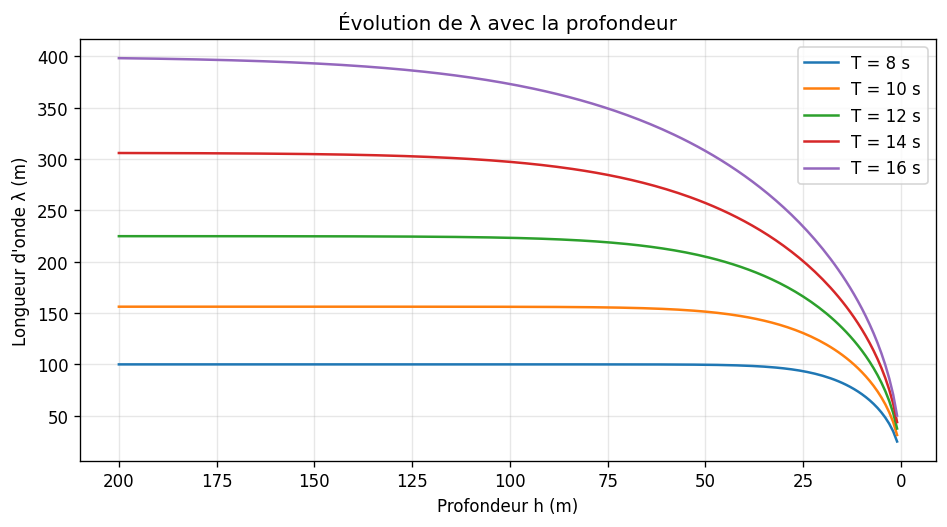

In [6]:
periodes = [8, 10, 12, 14, 16]
depths   = np.linspace(1, 200, 200)

fig, ax = plt.subplots(figsize=(8, 4.5))
for T in periodes:
    lambdas = [wave_properties(T, h)['lam'] for h in depths]
    ax.plot(depths, lambdas, label=f'T = {T} s')

ax.invert_xaxis()
ax.set_xlabel('Profondeur h (m)')
ax.set_ylabel('Longueur d\'onde λ (m)')
ax.set_title('Évolution de λ avec la profondeur')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:

# 1 : tracer c(h) et cg(h) sur le même graphe pour T=10s, 
# 2 : comparer λ numérique vs approximation eau profonde
# 3 : créer un tableau récapitulatif de conditions de houle (arbitraire)
#           T = [8, 12, 16] s, h = [10, 20, 50, 100, 150, 200] m


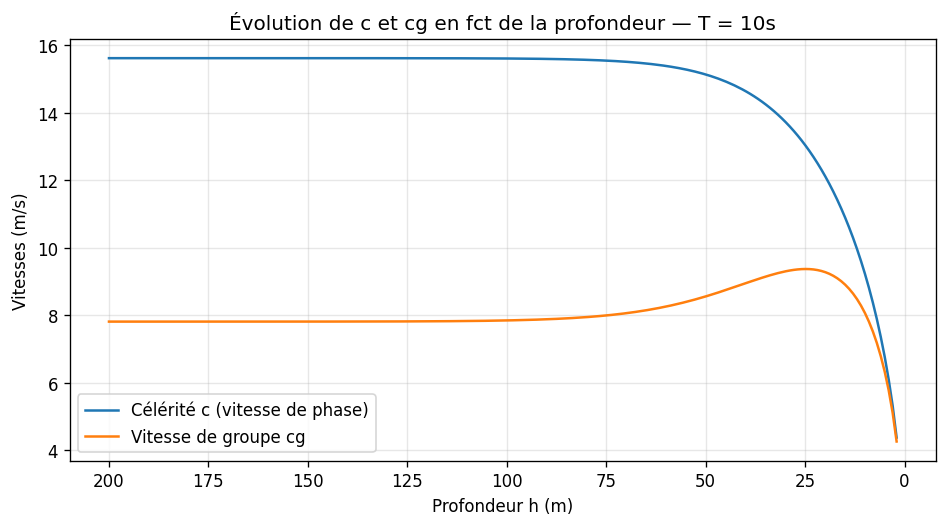

In [8]:
T = 10
depths = np.linspace(2, 200, 200)

c = [wave_properties(T, h)['c'] for h in depths]
cg = [wave_properties(T, h)['cg'] for h in depths]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(depths, c,  label='Célérité c (vitesse de phase)')
ax.plot(depths, cg, label='Vitesse de groupe cg')

ax.invert_xaxis()
ax.set_xlabel('Profondeur h (m)')
ax.set_ylabel('Vitesses (m/s)')
ax.set_title('Évolution de c et cg en fct de la profondeur — T = 10s')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:

# Pourquoi on obtient ça ? 

# car :  cg = ∂ω/∂k
# donc, cg = c/2 · (1 + 2kh/sinh(2kh)) = n · c 

# Ainsi,

# 1- Eau profonde (kh → ∞) :
#       sinh(2kh) → ∞  donc  2kh/sinh(2kh) → 0
#       n → 0.5 * (1 + 0) = 0.5
#       cg = c/2
# L'énergie voyage deux fois moins vite que la vague.

#2- Eau peu profonde (kh → 0) :
#      sinh(2kh) ≈ 2kh  donc  2kh/sinh(2kh) → 1
#      n → 0.5 * (1 + 1) = 1
#      cg = c
# L'énergie et la forme voyagent à la même vitesse.


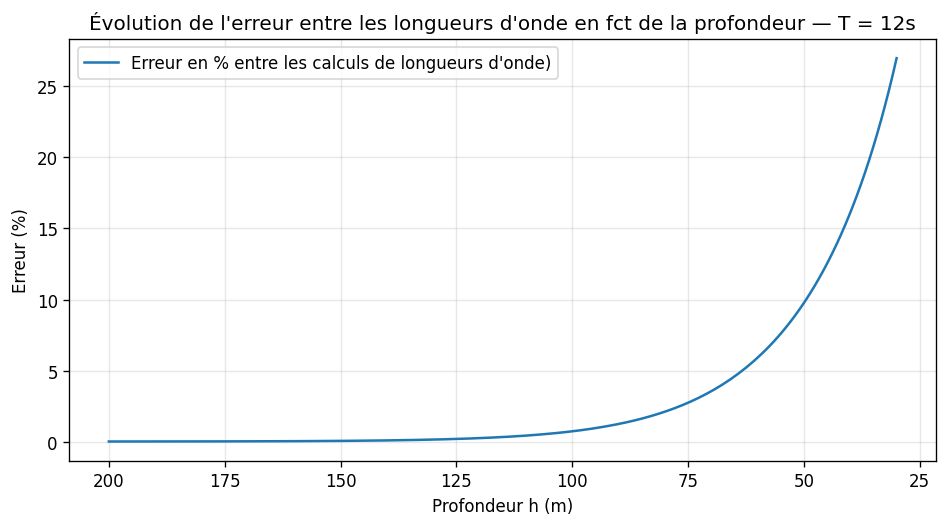

In [10]:
T = 12
depths = np.linspace(30, 200, 200)

Lambdas = [wave_properties(T, h)['lam'] for h in depths]
Lambda_0 = g * T**2 / (2 * np.pi)

Erreur = [abs(Lambdas[i] - Lambda_0)/Lambdas[i] * 100 for i in range (len(Lambdas))]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(depths, Erreur,  label='Erreur en % entre les calculs de longueurs d\'onde)')

ax.invert_xaxis()
ax.set_xlabel('Profondeur h (m)')
ax.set_ylabel('Erreur (%)')
ax.set_title('Évolution de l\'erreur entre les longueurs d\'onde en fct de la profondeur — T = 12s')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
periodes_example = [8, 12, 16]  
depths_example   = [10, 20, 50, 100, 150, 200] 

rows = []
for T in periodes_example:
    for h in depths_example:
        p = wave_properties(T, h)
        rows.append({
            'T (s)': T,
            'h (m)': h,
            'λ (m)': round(p['lam'], 1),
            'c (m/s)': round(p['c'], 2),
            'cg (m/s)': round(p['cg'], 2),
            'Régime': p['regime']
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

 T (s)  h (m)  λ (m)  c (m/s)  cg (m/s)                          Régime
     8     10   70.9     8.86      7.18 transitoire     (π/10 < kh < π)
     8     20   88.8    11.10      7.41 transitoire     (π/10 < kh < π)
     8     50   99.6    12.45      6.37        eau profonde    (kh > π)
     8    100   99.9    12.49      6.25        eau profonde    (kh > π)
     8    150   99.9    12.49      6.25        eau profonde    (kh > π)
     8    200   99.9    12.49      6.25        eau profonde    (kh > π)
    12     10  113.3     9.44      8.60 transitoire     (π/10 < kh < π)
    12     20  152.4    12.70     10.53 transitoire     (π/10 < kh < π)
    12     50  204.8    17.07     10.98 transitoire     (π/10 < kh < π)
    12    100  223.2    18.60      9.68 transitoire     (π/10 < kh < π)
    12    150  224.7    18.73      9.40        eau profonde    (kh > π)
    12    200  224.8    18.74      9.37        eau profonde    (kh > π)
    16     10  154.3     9.64      9.15 transitoire     (π/10 < 

In [12]:

# coeff de SHOALING (Ks)
# La conservation de l'énergie


In [29]:
# On voit grâce au tableau prédédent que on est en régime au profonde pour les 3 période à partir de 200m.
# Ainsi en profondeur de référence pour une "eau profonde" on choisit 200m.

def shoaling_coeff(T, h):
    h_p = 250  # eau profonde
    cg_h = wave_properties(T, h)['cg']
    cg_p = wave_properties(T, h_p)['cg']
    return np.sqrt(cg_p / cg_h)

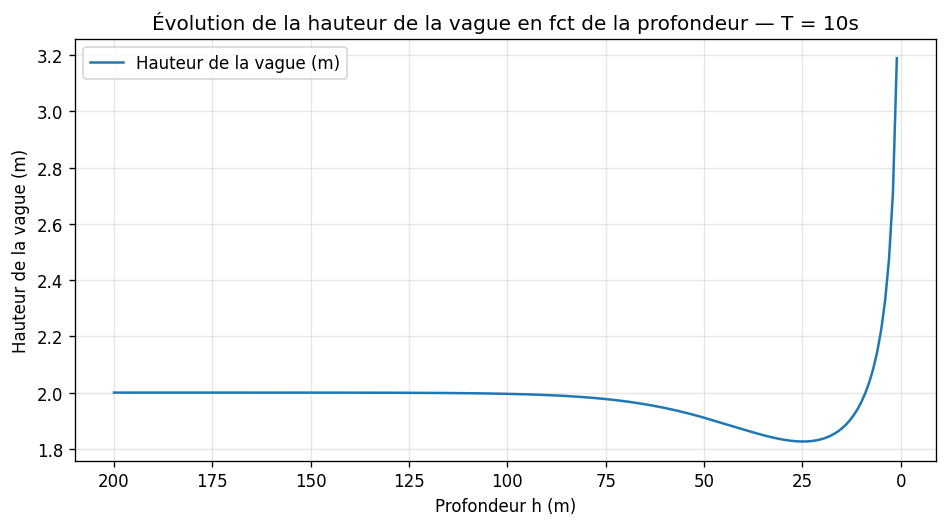

In [30]:
T = 10
depths = np.linspace(1, 200, 200)

Ks = [shoaling_coeff(T,h) for h in depths]

H0 = 2
H = [H0 * Ks[i] for i in range(len(Ks))]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(depths, H,  label='Hauteur de la vague (m)')

ax.invert_xaxis()
ax.set_xlabel('Profondeur h (m)')
ax.set_ylabel('Hauteur de la vague (m)')
ax.set_title('Évolution de la hauteur de la vague en fct de la profondeur — T = 10s')
ax.legend()
plt.tight_layout()
plt.show()

In [31]:

# Donc c'est normal, on à la bonne forme de vague, seulement il faut qu'elle déferle. 
# En effet une vague ça grimpe pas indéfiniment
# On fait ça avec ce critère : H = 0.142 * thanh(kh) * lam


In [32]:
def breaking_depth(T, H0):
    
    hmin = 1e-1    # profondeur de la borne initiale
    hp = 250   # profondeur correspondant à eau profonde -> borne final 
    
    def crit_miche(h):
        """Retourne 0 quand h est solution."""
        
        Ks = shoaling_coeff(T,h)
        H = H0 * Ks
        kh = wave_properties(T, h)['kh']
        lam = wave_properties(T, h)['lam']
        
        return H - 0.142 * np.tanh(kh) * lam
        
    return brentq(crit_miche, hmin, hp)

In [33]:
T = 10
H0 = 2  # hauteur au large en mètres

h_d = breaking_depth(T, H0)
H_d = H0 * shoaling_coeff(T, h_d)

print(f"Vérification H/h          : {H_d/h_d:.2f}")
print(f"Profondeur de déferlement : {h_d:.2f} m")
print(f"Hauteur au déferlement    : {H_d:.2f} m")

Vérification H/h          : 0.86
Profondeur de déferlement : 2.90 m
Hauteur au déferlement    : 2.49 m


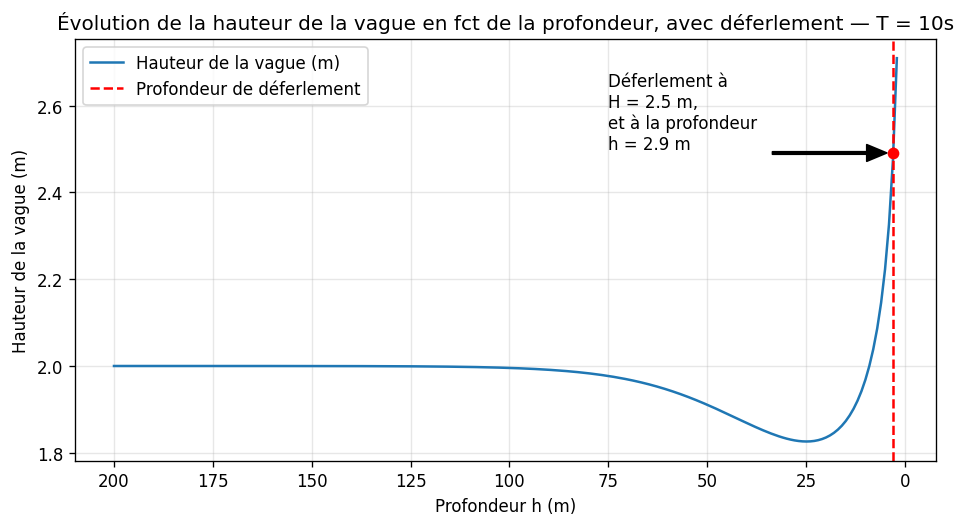

In [34]:
T = 10
depths = np.linspace(2, 200, 200)

Ks = [shoaling_coeff(T,h) for h in depths]

H0 = 2
H = [H0 * Ks[i] for i in range(len(Ks))]
h_d = breaking_depth(T, H0)
H_d = H0 * shoaling_coeff(T, h_d)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(depths, H,  label='Hauteur de la vague (m)')
ax.plot(h_d, H_d, 'ro')

plt.annotate(f'Déferlement à \nH = {H_d:.1f} m, \net à la profondeur \nh = {h_d:.1f} m', xy=(h_d, H_d), xytext=(75, 2.5), arrowprops=dict(facecolor='black', shrink=0.05, width = 1.5, headwidth = 10))
ax.invert_xaxis()
ax.axvline(x=h_d, color='red', linestyle='--', label='Profondeur de déferlement')
ax.set_xlabel('Profondeur h (m)')
ax.set_ylabel('Hauteur de la vague (m)')
ax.set_title('Évolution de la hauteur de la vague en fct de la profondeur, avec déferlement — T = 10s')
ax.legend()
plt.tight_layout()
plt.show()

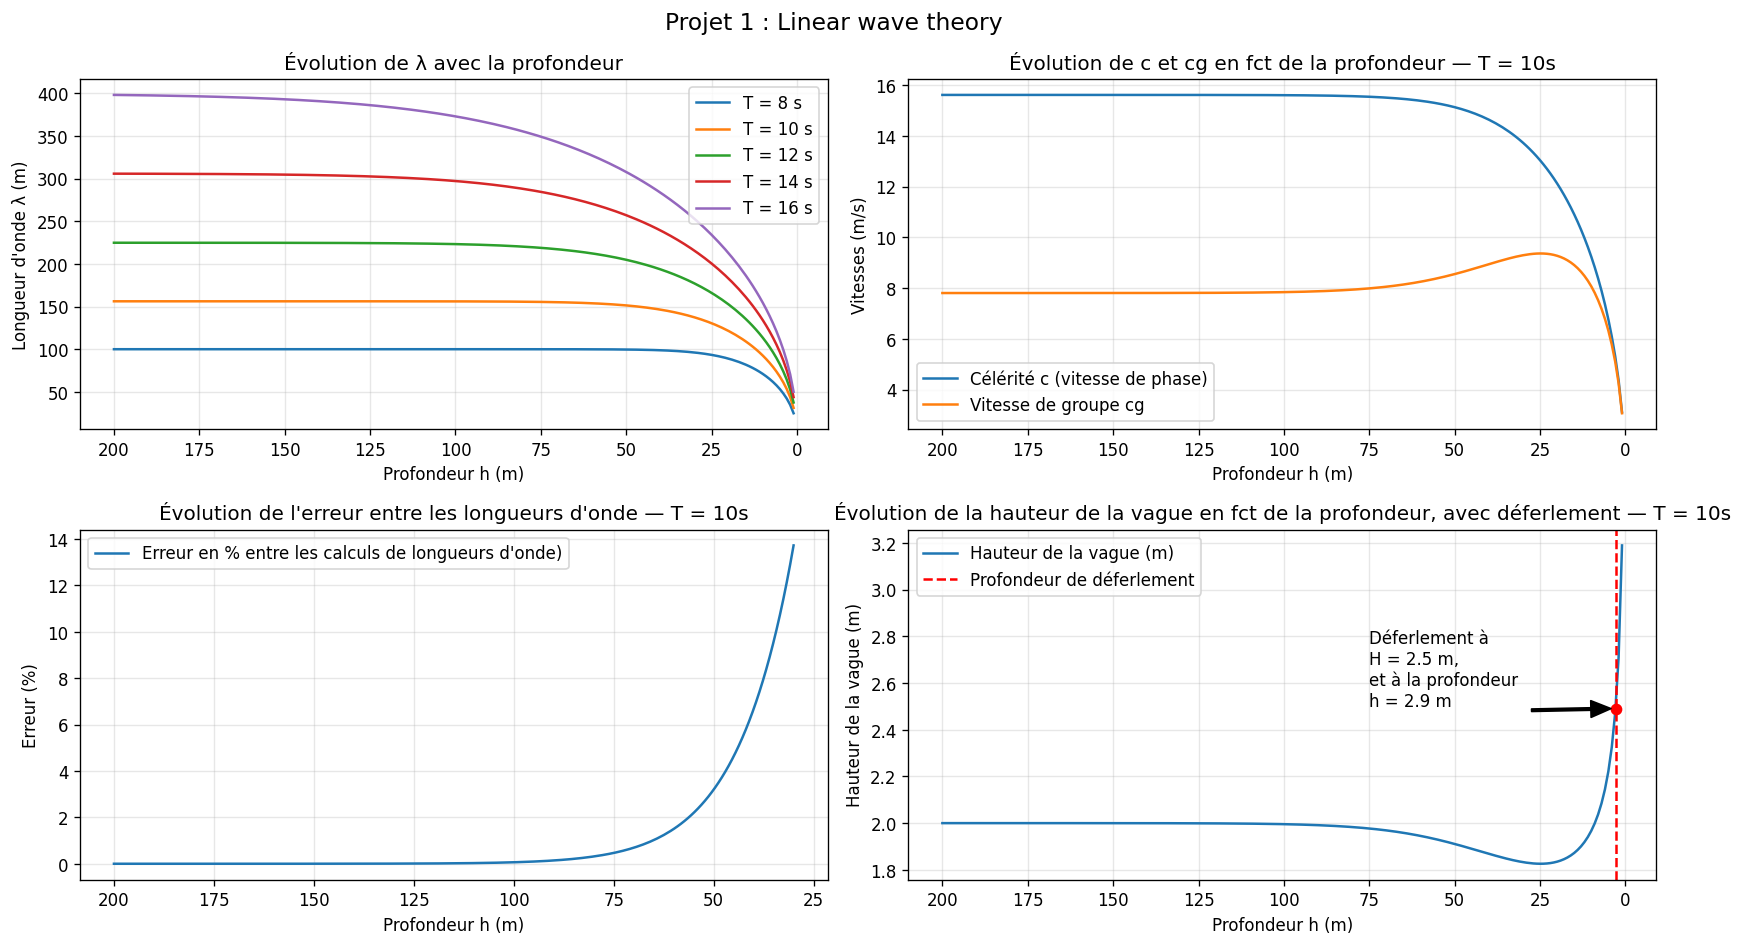

In [35]:
# Ensemble des graphs :)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Projet 1 : Linear wave theory', fontsize=14)

# Graph 1 — en haut à gauche
ax = axes[0, 0]
periodes = [8, 10, 12, 14, 16]
depths   = np.linspace(1, 200, 200)

for T in periodes:
    lambdas = [wave_properties(T, h)['lam'] for h in depths]
    ax.plot(depths, lambdas, label=f'T = {T} s')

ax.invert_xaxis()
ax.set_xlabel('Profondeur h (m)')
ax.set_ylabel('Longueur d\'onde λ (m)')
ax.set_title('Évolution de λ avec la profondeur')
ax.legend()

# Graph 2 — en haut à droite  
ax = axes[0, 1]
T = 10
depths = np.linspace(1, 200, 200)

c = [wave_properties(T, h)['c'] for h in depths]
cg = [wave_properties(T, h)['cg'] for h in depths]

ax.plot(depths, c,  label='Célérité c (vitesse de phase)')
ax.plot(depths, cg, label='Vitesse de groupe cg')

ax.invert_xaxis()
ax.set_xlabel('Profondeur h (m)')
ax.set_ylabel('Vitesses (m/s)')
ax.set_title('Évolution de c et cg en fct de la profondeur — T = 10s')
ax.legend()

# Graph 3 - en bas à gauche
ax = axes[1, 0]
T = 10
depths = np.linspace(30, 200, 200)

Lambdas = [wave_properties(T, h)['lam'] for h in depths]
Lambda_0 = g * T**2 / (2 * np.pi)

Erreur = [abs(Lambdas[i] - Lambda_0)/Lambdas[i] * 100 for i in range (len(Lambdas))]

ax.plot(depths, Erreur,  label='Erreur en % entre les calculs de longueurs d\'onde)')

ax.invert_xaxis()
ax.set_xlabel('Profondeur h (m)')
ax.set_ylabel('Erreur (%)')
ax.set_title('Évolution de l\'erreur entre les longueurs d\'onde — T = 10s')
ax.legend()

# Graph 4 — en bas à droite
ax = axes[1, 1]
T = 10
depths = np.linspace(1, 200, 200)

Ks = [shoaling_coeff(T,h) for h in depths]

H0 = 2
H = [H0 * Ks[i] for i in range(len(Ks))]
h_d = breaking_depth(T, H0)
H_d = H0 * shoaling_coeff(T, h_d)

ax.plot(depths, H,  label='Hauteur de la vague (m)')
ax.plot(h_d, H_d, 'ro')

ax.annotate(f'Déferlement à \nH = {H_d:.1f} m, \net à la profondeur \nh = {h_d:.1f} m', xy=(h_d, H_d), xytext=(75, 2.5), arrowprops=dict(facecolor='black', shrink=0.05, width = 1.5, headwidth = 10))
ax.invert_xaxis()
ax.axvline(x=h_d, color='red', linestyle='--', label='Profondeur de déferlement')
ax.set_xlabel('Profondeur h (m)')
ax.set_ylabel('Hauteur de la vague (m)')
ax.set_title('Évolution de la hauteur de la vague en fct de la profondeur, avec déferlement — T = 10s')
ax.legend()

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/dashboard_projet1.png', dpi=150)
plt.show()